In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [2]:
# =============================================================================
# PARAMETERS — edit this cell to explore how results change
# =============================================================================

# --- Vendor selection ---
VENDOR_SEED    = 2     # integer ≥ 0 — change to 'consult a different vendor'
PORTFOLIO_SEED = 42   # controls loan characteristics — keep fixed to compare vendors

# --- Flood hazard ---
RETURN_PERIOD = 20    # years — the CFRF/GARP data is for this event
# Annual exceedance probability = 1 / RETURN_PERIOD = 0.5%
# This enters the UNCONDITIONAL framing only (see Step 5).

# --- Probability framing ---
# "conditional"   — assumes the flood definitely occurs (p = 1.0)
#                   isolates vendor disagreement; natural for stress testing
# "unconditional" — weights stressed PD by the probability the flood occurs
#                   gives the expected ECL uplift; more natural for provisioning
# The notebook computes BOTH and compares them in the summary.

# --- Reduced-form transmission ---
ALPHA      = 2.0   # PD amplification:  PD_12m(d) = PD_0 × exp(α × d)
                   #   higher α → sharper PD response to damage
LAMBDA_LGD = 0.25  # LGD sensitivity:   LGD(d) = LGD_0 + λ × d
                   #   higher λ → losses worsen faster with damage

# --- IFRS 9 staging ---
TAU = 2.0          # SICR threshold: stage if PD_LT_stressed / PD_LT_base > τ
                   #   EBA benchmark = 2.0 (lifetime PD doubles)

# --- Loan portfolio draws ---
EAD_LOW,  EAD_HIGH  = 0.5,  5.0   # EAD £m, Uniform
PD_MU,    PD_SIGMA  = -5.5, 0.8   # baseline PD_12m log-normal (median ≈ 0.4%)
LGD_LOW,  LGD_HIGH  = 0.20, 0.45  # baseline LGD, Uniform
MAT_LOW,  MAT_HIGH  = 5,    25    # loan maturity years, discrete Uniform

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [3]:
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

# Triangular distribution parameters
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

# Working DataFrame — will accumulate columns step by step
results = pd.DataFrame({
    'property_rank': df['property_rank'],
    'd_min':  tri_a,
    'd_mean': df['mean_dr'].values,
    'd_max':  tri_b,
    'd_mode': tri_c,
})

# Sample one vendor
def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b) using inverse CDF."""
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u, 0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    x     = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)   # point mass → return a

vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)

results['d_vendor'] = d_vendor

# Construct loan portfolio
port_rng = np.random.default_rng(PORTFOLIO_SEED)

ead_m       = port_rng.uniform(EAD_LOW, EAD_HIGH, size=n)
pd_12m_base = np.clip(
    stats.lognorm.rvs(s=PD_SIGMA, scale=np.exp(PD_MU), size=n,
                      random_state=int(port_rng.integers(2**31))),
    1e-6, 0.9999
)
lgd_base    = port_rng.uniform(LGD_LOW, LGD_HIGH, size=n)
maturity    = port_rng.integers(MAT_LOW, MAT_HIGH + 1, size=n)
pd_lt_base  = 1.0 - (1.0 - pd_12m_base) ** maturity
ecl_base    = pd_12m_base * lgd_base * ead_m

results['ead_m']       = ead_m
results['pd_12m_base'] = pd_12m_base
results['lgd_base']    = lgd_base
results['maturity']    = maturity
results['pd_lt_base']  = pd_lt_base
results['ecl_base']    = ecl_base

# Damage transmission
pd_12m_str = np.clip(pd_12m_base * np.exp(ALPHA * d_vendor), 0, 0.9999)
lgd_str    = np.minimum(lgd_base + LAMBDA_LGD * d_vendor, 1.0)
pd_lt_str  = 1.0 - (1.0 - pd_12m_str) ** maturity

results['pd_12m_str'] = pd_12m_str
results['lgd_str']    = lgd_str
results['pd_lt_str']  = pd_lt_str

# IFRS Staging
p_annual  = 1.0 / RETURN_PERIOD                        # 0.005 for RP200
p_lifetime = 1.0 - (1.0 - p_annual) ** maturity        # per-loan lifetime flood prob

# ── Conditional framing (p = 1): flood is certain ────────────────────────────
sicr_cond  = pd_lt_str / pd_lt_base
stage_cond = np.where(sicr_cond > TAU, 2, 1)

# ── Unconditional framing: probability-weighted PDs ──────────────────────────
# 12-month: mixture over the coming year
pd_12m_uncond = (1.0 - p_annual)  * pd_12m_base + p_annual  * pd_12m_str
# Lifetime:  mixture over loan maturity
pd_lt_uncond  = (1.0 - p_lifetime) * pd_lt_base  + p_lifetime * pd_lt_str

sicr_uncond  = pd_lt_uncond / pd_lt_base
stage_uncond = np.where(sicr_uncond > TAU, 2, 1)

# Store both in results
results['p_lifetime']    = p_lifetime
results['sicr_cond']     = sicr_cond
results['stage_cond']    = stage_cond
results['sicr_uncond']   = sicr_uncond
results['stage_uncond']  = stage_uncond
results['pd_12m_uncond'] = pd_12m_uncond
results['pd_lt_uncond']  = pd_lt_uncond

# ECL calculation
def compute_ecl(pd_12m, pd_lt, lgd, ead, stage):
    """ECL = PD_12m × LGD × EAD (Stage 1) or PD_LT × LGD × EAD (Stage 2)."""
    return np.where(stage == 2, pd_lt * lgd * ead, pd_12m * lgd * ead)

# Conditional ECL (stressed PDs, stage from conditional SICR)
ecl_cond = compute_ecl(pd_12m_str, pd_lt_str, lgd_str, ead_m, stage_cond)

# Unconditional ECL (probability-adjusted PDs, stage from unconditional SICR)
ecl_uncond = compute_ecl(pd_12m_uncond, pd_lt_uncond, lgd_str, ead_m, stage_uncond)
# Note: LGD_stressed used in both cases — if default occurs after a flood,
# collateral recovery is impaired regardless of probability framing.

results['ecl_cond']   = ecl_cond
results['ecl_uncond'] = ecl_uncond

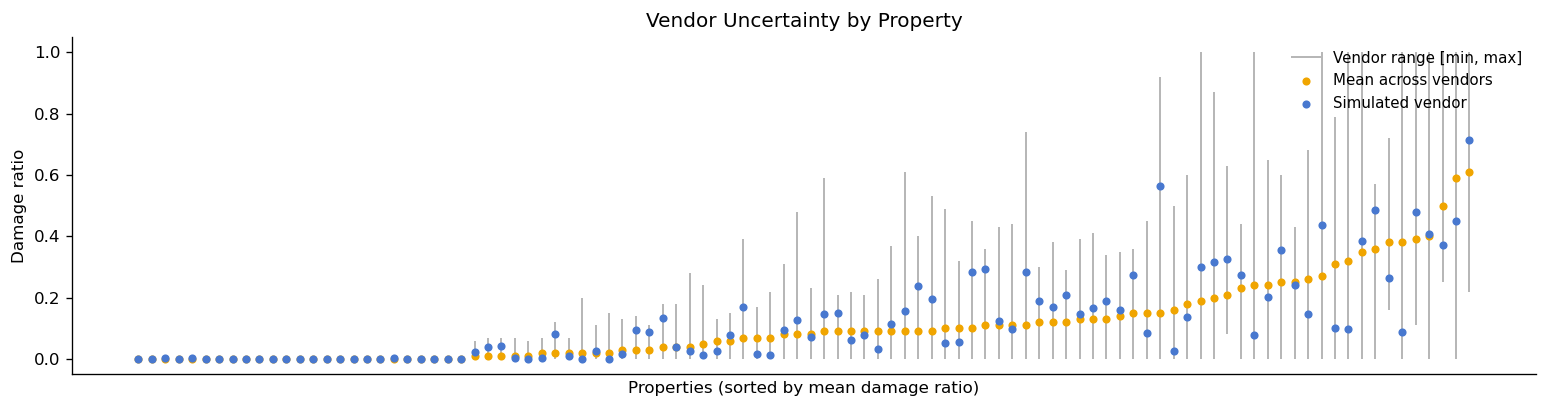

In [4]:
# Plot Spreads and Vendor sample
idx = np.argsort(results['d_mean'].values) # sort on GARP mean value
mean_d = results['d_mean'].values[idx]
min_d = results['d_min'].values[idx]
max_d = results['d_max'].values[idx]
x_pos = np.arange((idx>=0).sum())
vendor_d = results['d_vendor'].values[idx] 

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.vlines(x_pos,min_d, max_d, color=GREY, linewidth=1.2, alpha=0.6,
          label='Vendor range [min, max]')
ax.scatter(x_pos, mean_d, color=AMBER, s=15, zorder=3, label='Mean across vendors')
ax.scatter(x_pos, vendor_d, color=BLUE, s=15, zorder=3, label='Simulated vendor')

ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio')
ax.set_title('Vendor Uncertainty by Property')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

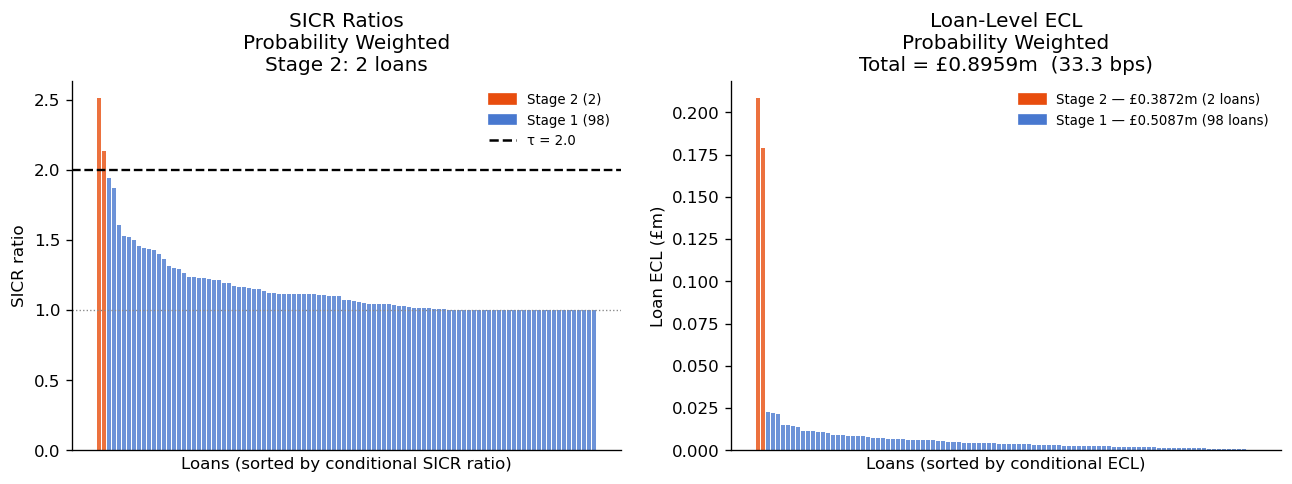

In [5]:
# Plot SCIR Ratios and ECL
prob_weighting = True # are we probability weighting or not

if prob_weighting:
    sicr = results['sicr_uncond'].values
    ecl = results['ecl_uncond'].values
    stage = results['stage_uncond'].values
    title = 'Probability Weighted'
else:
    sicr = results['sicr_cond'].values
    ecl = results['ecl_cond'].values
    stage = results['stage_cond'].values
    title = 'Non-probability Weighted'

sicr_order = np.argsort(sicr)[::-1]
ecl_order = np.argsort(ecl)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# PLOT SICR GRAPH
sicr_colors = [RED if s == 2 else BLUE for s in stage[sicr_order]]
axes[0].bar(np.arange(n), sicr[sicr_order], color=sicr_colors, width=0.8, alpha=0.8)
axes[0].axhline(TAU, color='black', linewidth=1.4, linestyle='--', label=f'τ = {TAU}')
axes[0].axhline(1.0, color=GREY, linewidth=0.8, linestyle=':')
n_s2 = (stage == 2).sum()
axes[0].set_xlabel('Loans (sorted by conditional SICR ratio)')
axes[0].set_ylabel('SICR ratio')
axes[0].set_title(f'SICR Ratios\n{title}\nStage 2: {n_s2} loans')
axes[0].set_xticks([])
legend_handles = [
        mpatches.Patch(color=RED,  label=f'Stage 2 ({n_s2})'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 ({n - n_s2})'),
        plt.Line2D([0],[0], color='black', linestyle='--', label=f'τ = {TAU}'),
    ]
axes[0].legend(handles=legend_handles, frameon=False, fontsize=8)
# PLOT ECL GRAPH
ecl_colors = [RED if s == 2 else BLUE for s in stage[ecl_order]]
axes[1].bar(np.arange(n), ecl[ecl_order], color=ecl_colors, width=0.8, alpha=0.8)
ecl_s1 = ecl[stage == 1].sum()
ecl_s2 = ecl[stage == 2].sum()
n_s2   = (stage == 2).sum()
axes[1].set_xlabel('Loans (sorted by conditional ECL)')
axes[1].set_ylabel('Loan ECL (£m)')
axes[1].set_title(f'Loan-Level ECL\n{title}\nTotal = £{ecl.sum():.4f}m  ({ecl.sum()/ead_m.sum()*1e4:.1f} bps)')
axes[1].set_xticks([])
legend_handles = [
    mpatches.Patch(color=RED,  label=f'Stage 2 — £{ecl_s2:.4f}m ({n_s2} loans)'),
    mpatches.Patch(color=BLUE, label=f'Stage 1 — £{ecl_s1:.4f}m ({n - n_s2} loans)'),
]
axes[1].legend(handles=legend_handles, frameon=False, fontsize=8)

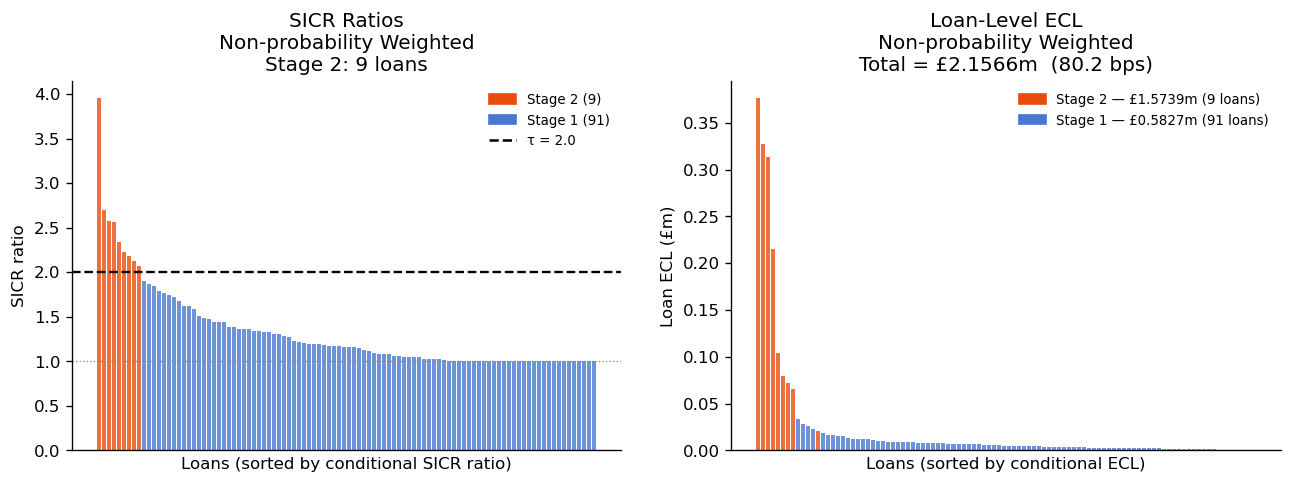

In [6]:
# Plot SCIR Ratios and ECL
prob_weighting = False # are we probability weighting or not

if prob_weighting:
    sicr = results['sicr_uncond'].values
    ecl = results['ecl_uncond'].values
    stage = results['stage_uncond'].values
    title = 'Probability Weighted'
else:
    sicr = results['sicr_cond'].values
    ecl = results['ecl_cond'].values
    stage = results['stage_cond'].values
    title = 'Non-probability Weighted'

sicr_order = np.argsort(sicr)[::-1]
ecl_order = np.argsort(ecl)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# PLOT SICR GRAPH
sicr_colors = [RED if s == 2 else BLUE for s in stage[sicr_order]]
axes[0].bar(np.arange(n), sicr[sicr_order], color=sicr_colors, width=0.8, alpha=0.8)
axes[0].axhline(TAU, color='black', linewidth=1.4, linestyle='--', label=f'τ = {TAU}')
axes[0].axhline(1.0, color=GREY, linewidth=0.8, linestyle=':')
n_s2 = (stage == 2).sum()
axes[0].set_xlabel('Loans (sorted by conditional SICR ratio)')
axes[0].set_ylabel('SICR ratio')
axes[0].set_title(f'SICR Ratios\n{title}\nStage 2: {n_s2} loans')
axes[0].set_xticks([])
legend_handles = [
        mpatches.Patch(color=RED,  label=f'Stage 2 ({n_s2})'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 ({n - n_s2})'),
        plt.Line2D([0],[0], color='black', linestyle='--', label=f'τ = {TAU}'),
    ]
axes[0].legend(handles=legend_handles, frameon=False, fontsize=8)
# PLOT ECL GRAPH
ecl_colors = [RED if s == 2 else BLUE for s in stage[ecl_order]]
axes[1].bar(np.arange(n), ecl[ecl_order], color=ecl_colors, width=0.8, alpha=0.8)
ecl_s1 = ecl[stage == 1].sum()
ecl_s2 = ecl[stage == 2].sum()
n_s2   = (stage == 2).sum()
axes[1].set_xlabel('Loans (sorted by conditional ECL)')
axes[1].set_ylabel('Loan ECL (£m)')
axes[1].set_title(f'Loan-Level ECL\n{title}\nTotal = £{ecl.sum():.4f}m  ({ecl.sum()/ead_m.sum()*1e4:.1f} bps)')
axes[1].set_xticks([])
legend_handles = [
    mpatches.Patch(color=RED,  label=f'Stage 2 — £{ecl_s2:.4f}m ({n_s2} loans)'),
    mpatches.Patch(color=BLUE, label=f'Stage 1 — £{ecl_s1:.4f}m ({n - n_s2} loans)'),
]
axes[1].legend(handles=legend_handles, frameon=False, fontsize=8)

In [7]:
# =============================================================================
# Helper: run the full ECL calculation for one set of parameters
# Uses the notebook-level parameters as defaults, so you only need to pass
# the parameter you want to change.
# =============================================================================

def run_one(
    vendor_seed    = None,   # if None, uses VENDOR_SEED
    portfolio_seed = None,   # if None, uses PORTFOLIO_SEED
    alpha          = None,
    lambda_lgd     = None,
    tau            = None,
    return_period  = None,
):
    """
    Run the full reduced-form ECL calculation for one parameter combination.

    All arguments default to the notebook-level parameter values, so you can
    call run_one(vendor_seed=5) to change only the vendor and keep everything
    else fixed.

    Returns a dict with portfolio-level summary statistics.
    """
    vs  = VENDOR_SEED    if vendor_seed    is None else vendor_seed
    ps  = PORTFOLIO_SEED if portfolio_seed is None else portfolio_seed
    a   = ALPHA          if alpha          is None else alpha
    lam = LAMBDA_LGD     if lambda_lgd     is None else lambda_lgd
    t   = TAU            if tau            is None else tau
    rp  = RETURN_PERIOD  if return_period  is None else return_period

    # Vendor sample
    d = triangular_sample(np.random.default_rng(vs), tri_a, tri_b, tri_c)

    # Loan portfolio
    rng = np.random.default_rng(ps)
    ead   = rng.uniform(EAD_LOW, EAD_HIGH, size=n)
    pd0   = np.clip(stats.lognorm.rvs(s=PD_SIGMA, scale=np.exp(PD_MU), size=n,
                                       random_state=int(rng.integers(2**31))), 1e-6, 0.9999)
    lgd0  = rng.uniform(LGD_LOW, LGD_HIGH, size=n)
    mat   = rng.integers(MAT_LOW, MAT_HIGH + 1, size=n)
    pd_lt_b = 1.0 - (1.0 - pd0) ** mat
    ecl_b   = pd0 * lgd0 * ead

    # Transmission
    pd_str    = np.clip(pd0 * np.exp(a * d), 0, 0.9999)
    lgd_str   = np.minimum(lgd0 + lam * d, 1.0)
    pd_lt_str = 1.0 - (1.0 - pd_str) ** mat

    # Staging & ECL — conditional
    sicr_c  = pd_lt_str / pd_lt_b
    stage_c = np.where(sicr_c > t, 2, 1)
    ecl_c   = np.where(stage_c == 2, pd_lt_str * lgd_str * ead,
                                     pd_str    * lgd_str * ead)

    # Staging & ECL — unconditional
    p_a    = 1.0 / rp
    p_lt   = 1.0 - (1.0 - p_a) ** mat
    pd12_u = (1 - p_a)  * pd0     + p_a  * pd_str
    pdlt_u = (1 - p_lt) * pd_lt_b + p_lt * pd_lt_str
    sicr_u = pdlt_u / pd_lt_b
    stage_u = np.where(sicr_u > t, 2, 1)
    ecl_u   = np.where(stage_u == 2, pdlt_u * lgd_str * ead,
                                     pd12_u * lgd_str * ead)

    ead_tot = ead.sum()
    return {
        'ecl_base':       ecl_b.sum(),
        'ecl_cond':       ecl_c.sum(),
        'ecl_uncond':     ecl_u.sum(),
        'ecl_cond_bps':   ecl_c.sum() / ead_tot * 1e4,
        'ecl_uncond_bps': ecl_u.sum() / ead_tot * 1e4,
        'n_s2_cond':      int((stage_c == 2).sum()),
        'n_s2_uncond':    int((stage_u == 2).sum()),
        'ead_total':      ead_tot,
    }


def _bar_width(x):
    """Sensible bar width for a sensitivity sweep — avoids overlapping bars."""
    if len(x) < 2:
        return 0.4
    gaps = np.diff(np.sort(x))
    return float(gaps.min()) * 0.6 if gaps.min() > 0 else 0.4


# Quick check — should match the main calculation cell above
ref = run_one()
print(f'run_one() check — conditional ECL: £{ref["ecl_cond"]:.4f}m, '
      f'Stage 2: {ref["n_s2_cond"]} loans')

run_one() check — conditional ECL: £2.1566m, Stage 2: 9 loans


In [ ]:
# =============================================================================
# SENSITIVITY ANALYSIS
# Change SWEEP_PARAM and SWEEP_VALUES to explore any parameter.
# Everything else stays fixed at the notebook-level parameter values.
# =============================================================================

SWEEP_PARAM  = 'vendor_seed'           # which parameter to vary
SWEEP_VALUES = list(range(0, 1000))      # values to loop over

# Other ready-to-use configurations — uncomment one:
# SWEEP_PARAM = 'portfolio_seed';  SWEEP_VALUES = list(range(0, 30))
# SWEEP_PARAM = 'alpha';           SWEEP_VALUES = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
# SWEEP_PARAM = 'lambda_lgd';      SWEEP_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
# SWEEP_PARAM = 'tau';             SWEEP_VALUES = [1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
# SWEEP_PARAM = 'return_period';   SWEEP_VALUES = [20, 50, 100, 200, 500, 1000]

# --- Run sweep ---
rows = []
for val in SWEEP_VALUES:
    res = run_one(**{SWEEP_PARAM: val})
    rows.append({'param_value': val, **res})

sweep = pd.DataFrame(rows)

# --- Summary table ---
print(f'Sensitivity sweep: {SWEEP_PARAM}')
print(f'Fixed parameters: α={ALPHA}, λ={LAMBDA_LGD}, τ={TAU}, '
      f'RP={RETURN_PERIOD}, vendor={VENDOR_SEED}, portfolio={PORTFOLIO_SEED}')
print()
print(sweep[['param_value', 'ecl_cond', 'ecl_cond_bps', 'n_s2_cond',
             'ecl_uncond', 'ecl_uncond_bps', 'n_s2_uncond']]
      .rename(columns={
          'param_value':    SWEEP_PARAM,
          'ecl_cond':       'ECL_cond (£m)',
          'ecl_cond_bps':   'ECL_cond (bps)',
          'n_s2_cond':      'Stage2_cond',
          'ecl_uncond':     'ECL_uncond (£m)',
          'ecl_uncond_bps': 'ECL_uncond (bps)',
          'n_s2_uncond':    'Stage2_uncond',
      })
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# --- Plot ---
current_val = {
    'vendor_seed': VENDOR_SEED, 'portfolio_seed': PORTFOLIO_SEED,
    'alpha': ALPHA, 'lambda_lgd': LAMBDA_LGD,
    'tau': TAU, 'return_period': RETURN_PERIOD,
}.get(SWEEP_PARAM)

x = sweep['param_value'].values
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: ECL vs parameter
ax = axes[0]
ax.plot(x, sweep['ecl_cond'],   color=RED,  marker='o', markersize=5,
        linewidth=1.5, label='Conditional (flood certain)')
ax.plot(x, sweep['ecl_uncond'], color=BLUE, marker='o', markersize=5,
        linewidth=1.5, label=f'Unconditional (p=1/{RETURN_PERIOD})')
ax.axhline(sweep['ecl_base'].iloc[0], color=GREY, linewidth=1.0,
           linestyle=':', label='Baseline (no flood)')
if current_val is not None and current_val in SWEEP_VALUES:
    ax.axvline(current_val, color=GREY, linewidth=1.0, linestyle='--',
               alpha=0.7, label=f'Current value ({current_val})')
ax.set_xlabel(SWEEP_PARAM)
ax.set_ylabel('Total portfolio ECL (£m)')
ax.set_title(f'ECL vs {SWEEP_PARAM}')
ax.legend(frameon=False, fontsize=8)

# Right: Stage 2 loan count vs parameter
ax2 = axes[1]
ax2.bar(x, sweep['n_s2_cond'], color=RED, alpha=0.7, width=_bar_width(x),
        label='Conditional')
ax2.bar(x, sweep['n_s2_uncond'], color=BLUE, alpha=0.7, width=_bar_width(x),
        label='Unconditional', bottom=0)
if current_val is not None and current_val in SWEEP_VALUES:
    ax2.axvline(current_val, color=GREY, linewidth=1.0, linestyle='--', alpha=0.7)
ax2.set_xlabel(SWEEP_PARAM)
ax2.set_ylabel('Loans in Stage 2')
ax2.set_title(f'Stage 2 loan count vs {SWEEP_PARAM}')
ax2.legend(frameon=False, fontsize=8)

fig.suptitle(
    f'Sensitivity: {SWEEP_PARAM}  |  '
    f'α={ALPHA}, λ={LAMBDA_LGD}, τ={TAU}, RP={RETURN_PERIOD}',
    fontsize=9, y=1.01
)
plt.tight_layout()
plt.show()

Sensitivity sweep: vendor_seed
Fixed parameters: α=2.0, λ=0.25, τ=2.0, RP=20, vendor=2, portfolio=42

 vendor_seed  ECL_cond (£m)  ECL_cond (bps)  Stage2_cond  ECL_uncond (£m)  ECL_uncond (bps)  Stage2_uncond
           0          3.379         125.587           14            1.885            70.084              6
           1          3.569         132.673           11            1.756            65.285              5
           2          2.157          80.163            9            0.896            33.302              2
           3          2.113          78.560            8            1.415            52.594              4
           4          3.553         132.066           15            1.921            71.418              6
           5          2.211          82.200            8            1.351            50.233              4
           6          3.137         116.597           10            1.146            42.615              3
           7          4.474         166.32

---
## Global Sensitivity Analysis — Sobol Indices

The one-at-a-time sweep above holds all other parameters fixed, so it misses
**interaction effects**: e.g. does α matter more when τ is low?

**Variance-based (Sobol) GSA** answers this properly. It samples all parameters
simultaneously across their full ranges and decomposes the variance of portfolio
ECL into contributions from each parameter:

| Index | Meaning |
|---|---|
| **S1** (first-order) | Fraction of ECL variance explained by this parameter *alone* |
| **ST** (total-order) | Fraction including all interactions with other parameters |
| **ST − S1** | Variance attributable purely to interactions |

Parameters varied:

| Parameter | Range | Represents |
|---|---|---|
| `alpha` | [0.5, 5.0] | Analyst's choice of PD sensitivity |
| `lambda_lgd` | [0.0, 0.5] | Analyst's choice of LGD sensitivity |
| `tau` | [1.0, 3.0] | SICR staging threshold |
| `vendor_seed` | [0, 999] | Which vendor the FI happens to use |
| `portfolio_seed` | [0, 999] | Loan book composition uncertainty |

`return_period` is excluded here because it has no effect on the *conditional*
ECL framing (the flood is treated as certain regardless of RP). It matters only
for the unconditional framing — see the note at the end of the cell.

In [102]:
from SALib.sample import sobol as sobol_sample   # replaces deprecated saltelli
from SALib.analyze import sobol as sobol_analyze

# =============================================================================
# GSA CONFIGURATION — edit these to change the analysis
# =============================================================================

GSA_N = 1024   # Saltelli base sample size; total model runs = N × (2k + 2)
               # k=5 parameters → 12,288 runs at N=1024. Increase for tighter CIs.

GSA_PROBLEM = {
    'num_vars': 5,
    'names':  ['alpha', 'lambda_lgd', 'tau', 'vendor_seed', 'portfolio_seed'],
    'bounds': [
        [0.5,  3.0],   # alpha:          plausible range for PD amplification
        [0.0,  0.5],   # lambda_lgd:     plausible range for LGD sensitivity
        [1.5,  2.5],   # tau:            from lenient (1.0) to conservative (3.0)
        [0,    999],   # vendor_seed:    1000 hypothetical vendors
        [0,    999],   # portfolio_seed: 1000 hypothetical loan books
    ],
}

# =============================================================================
# Run the model across all Saltelli samples
# =============================================================================

param_values = sobol_sample.sample(GSA_PROBLEM, GSA_N, calc_second_order=False)
print(f'Running {len(param_values):,} model evaluations '
      f'({GSA_N} × (2×{GSA_PROBLEM["num_vars"]}+2))...')

Y_cond   = np.zeros(len(param_values))
Y_uncond = np.zeros(len(param_values))

for i, p in enumerate(param_values):
    res = run_one(
        alpha          = float(p[0]),
        lambda_lgd     = float(p[1]),
        tau            = float(p[2]),
        vendor_seed    = int(p[3]),
        portfolio_seed = int(p[4]),
    )
    Y_cond[i]   = res['ecl_cond']
    Y_uncond[i] = res['ecl_uncond']

print(f'Done.  ECL_cond:   mean=£{Y_cond.mean():.3f}m  std=£{Y_cond.std():.3f}m')
print(f'       ECL_uncond: mean=£{Y_uncond.mean():.3f}m  std=£{Y_uncond.std():.3f}m')

# =============================================================================
# Compute Sobol indices
# =============================================================================

Si_cond   = sobol_analyze.analyze(GSA_PROBLEM, Y_cond,   calc_second_order=False,
                                   print_to_console=False)
Si_uncond = sobol_analyze.analyze(GSA_PROBLEM, Y_uncond, calc_second_order=False,
                                   print_to_console=False)

names = GSA_PROBLEM['names']
gsa_df = pd.DataFrame({
    'Parameter':    names,
    'S1_cond':      Si_cond['S1'],
    'S1_cond_CI':   Si_cond['S1_conf'],
    'ST_cond':      Si_cond['ST'],
    'ST_cond_CI':   Si_cond['ST_conf'],
    'S1_uncond':    Si_uncond['S1'],
    'S1_uncond_CI': Si_uncond['S1_conf'],
    'ST_uncond':    Si_uncond['ST'],
    'ST_uncond_CI': Si_uncond['ST_conf'],
})

print('\nSobol indices — Conditional ECL (flood certain)')
print(gsa_df[['Parameter','S1_cond','S1_cond_CI','ST_cond','ST_cond_CI']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print('\nSobol indices — Unconditional ECL (probability-weighted)')
print(gsa_df[['Parameter','S1_uncond','S1_uncond_CI','ST_uncond','ST_uncond_CI']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Running 7,168 model evaluations (1024 × (2×5+2))...
Done.  ECL_cond:   mean=£2.878m  std=£2.156m
       ECL_uncond: mean=£0.592m  std=£0.156m

Sobol indices — Conditional ECL (flood certain)
     Parameter  S1_cond  S1_cond_CI  ST_cond  ST_cond_CI
         alpha    0.627       0.070    0.760       0.081
    lambda_lgd    0.041       0.022    0.063       0.009
           tau    0.068       0.027    0.095       0.014
   vendor_seed    0.053       0.037    0.134       0.016
portfolio_seed    0.062       0.032    0.132       0.015

Sobol indices — Unconditional ECL (probability-weighted)
     Parameter  S1_uncond  S1_uncond_CI  ST_uncond  ST_uncond_CI
         alpha      0.090         0.070      0.536         0.181
    lambda_lgd      0.054         0.023      0.117         0.033
           tau      0.018         0.073      0.443         0.139
   vendor_seed      0.041         0.075      0.455         0.140
portfolio_seed      0.237         0.069      0.528         0.119


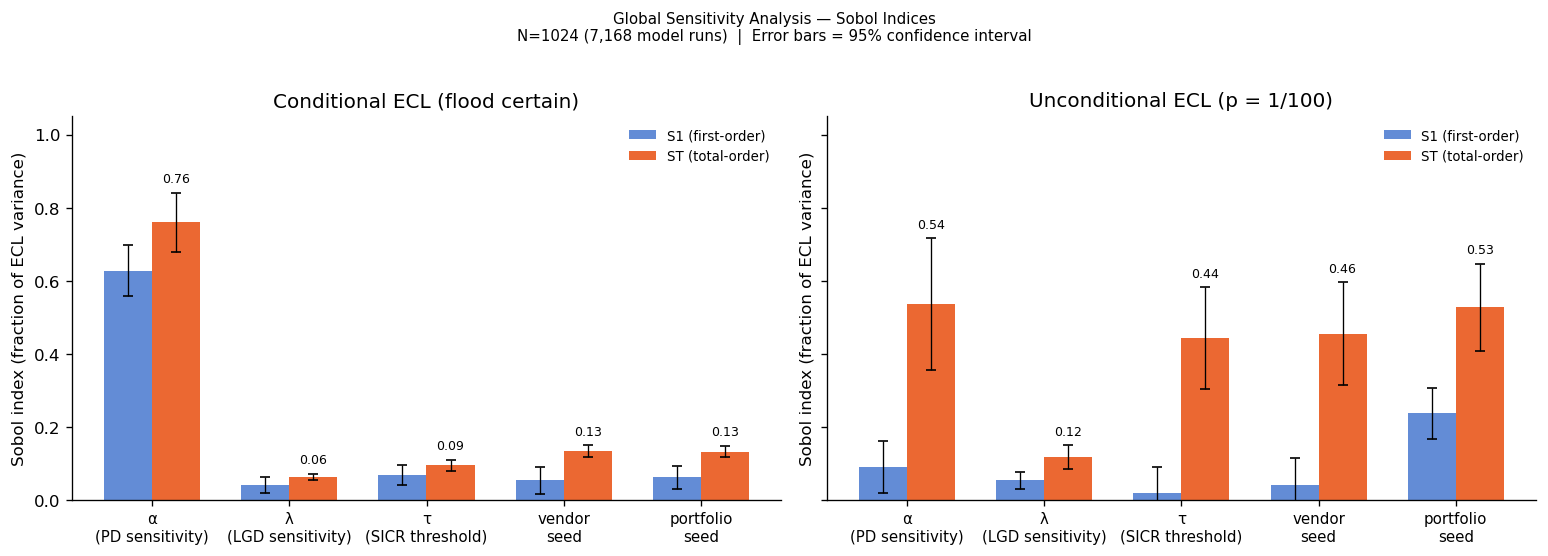

Interpretation guide:
  S1 ≈ ST       → parameter acts mostly independently (no strong interactions)
  ST >> S1      → parameter is important mainly through interactions
  S1 ≈ ST ≈ 0   → parameter has negligible influence on ECL variance
  ΣST > 1       → interactions present in the model (expected here)

For the paper: if vendor_seed has meaningful ST, it means vendor selection
contributes to ECL variance *alongside* model parameter uncertainty — i.e.
the choice of vendor is as important as the choice of α or τ.


In [103]:
# =============================================================================
# Plot Sobol indices — conditional and unconditional side by side
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

bar_w   = 0.35
x       = np.arange(len(names))
labels  = ['α\n(PD sensitivity)', 'λ\n(LGD sensitivity)', 'τ\n(SICR threshold)',
           'vendor\nseed', 'portfolio\nseed']

for ax, framing, s1, s1_ci, st, st_ci, title in [
    (axes[0], 'Conditional',
     Si_cond['S1'],   Si_cond['S1_conf'],
     Si_cond['ST'],   Si_cond['ST_conf'],
     'Conditional ECL (flood certain)'),
    (axes[1], 'Unconditional',
     Si_uncond['S1'], Si_uncond['S1_conf'],
     Si_uncond['ST'], Si_uncond['ST_conf'],
     f'Unconditional ECL (p = 1/{RETURN_PERIOD})'),
]:
    ax.bar(x - bar_w/2, np.maximum(s1, 0), bar_w,
           color=BLUE, alpha=0.85, label='S1 (first-order)',
           yerr=s1_ci, capsize=3, error_kw=dict(linewidth=0.8))
    ax.bar(x + bar_w/2, np.maximum(st, 0), bar_w,
           color=RED,  alpha=0.85, label='ST (total-order)',
           yerr=st_ci, capsize=3, error_kw=dict(linewidth=0.8))

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Sobol index (fraction of ECL variance)')
    ax.set_ylim(0, 1.05)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)

    # Annotate ST values above bars
    for i, (s1v, stv) in enumerate(zip(s1, st)):
        if stv > 0.02:
            ax.text(i + bar_w/2, min(stv + st_ci[i] + 0.02, 1.0),
                    f'{stv:.2f}', ha='center', va='bottom', fontsize=7.5)

fig.suptitle(
    f'Global Sensitivity Analysis — Sobol Indices\n'
    f'N={GSA_N} ({len(param_values):,} model runs)  |  '
    f'Error bars = 95% confidence interval',
    fontsize=9, y=1.02
)
plt.tight_layout()
plt.show()

# =============================================================================
# Interpretation notes
# =============================================================================
print('Interpretation guide:')
print('  S1 ≈ ST       → parameter acts mostly independently (no strong interactions)')
print('  ST >> S1      → parameter is important mainly through interactions')
print('  S1 ≈ ST ≈ 0   → parameter has negligible influence on ECL variance')
print('  ΣST > 1       → interactions present in the model (expected here)')
print()
print('For the paper: if vendor_seed has meaningful ST, it means vendor selection')
print('contributes to ECL variance *alongside* model parameter uncertainty — i.e.')
print('the choice of vendor is as important as the choice of α or τ.')